# Agentic AI ROI Model — Luxury Goods Industry

Analyzes the potential ROI of deploying agentic AI in luxury retail, incorporating **OSINT-derived customer retention metrics** from the luxury sector.

**Datasets:**
- Training: `luxury_goods_mock_only_1000.xlsx` (synthetic survey data)
- Evaluation: `Luxury Goods Shopping Experince_March 11, 2026_17.48.xlsx` (real survey data)

**Approach:** Train/test split with XGBoost, Random Forest, and Gradient Boosting regressors. The ROI target incorporates OSINT luxury industry customer retention benchmarks (Bain, McKinsey, Deloitte, BCG).

## 1. Setup & Imports

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

## 2. OSINT: Luxury Industry Customer Retention Benchmarks

| Source | Metric | Value |
|---|---|---|
| Bain & Company | Baseline luxury retention rate | 82% |
| McKinsey | AI-enhanced retention uplift | 10–20% |
| BCG x Altagamma | CLV multiplier for retained customers | 8.5x annual spend |
| Deloitte | New customer acquisition cost vs retention | 5x |
| McKinsey | AI personalization revenue lift | ~20% |
| Industry avg | AI implementation cost ratio | ~3% of revenue |

In [26]:
OSINT_RETENTION = {
    'baseline_retention_rate': 0.82,
    'ai_enhanced_retention_uplift': 0.15,
    'avg_luxury_clv_multiplier': 8.5,
    'churn_cost_multiplier': 5.0,
    'personalization_revenue_lift': 0.20,
    'ai_implementation_cost_ratio': 0.03,
    'digital_engagement_retention_boost': 0.12,
    'income_tier_clv': {
        'Under $25,000': 1_500,
        '$25,000–$49,999': 3_500,
        '$50,000–$99,999': 7_000,
        '$100,000–$199,999': 15_000,
        '$200,000–$499,999': 35_000,
        '$500,000+': 75_000,
    },
    'purchase_frequency_weight': {
        'Multiple times per year': 1.0,
        'Once per year': 0.6,
        'Every few years': 0.3,
        'Rarely': 0.15,
        'Never': 0.05,
    },
    'age_digital_propensity': {
        'Under 18': 0.85, '18–24': 0.92, '25–34': 0.88,
        '35–44': 0.75, '45–54': 0.60, '55–64': 0.45, '65+': 0.30,
    }
}
R = OSINT_RETENTION
print("OSINT retention benchmarks loaded.")

OSINT retention benchmarks loaded.


## 3. Data Cleaning Configuration

The Qualtrics export embeds question text in data cells. We define valid response values per column — anything else is coerced to NaN.

In [27]:
VALID_VALUES = {
    'Q1': {'Under 18', '18–24', '25–34', '35–44', '45–54', '55–64', '65+'},
    'Q2': {'Male', 'Female', 'Non-binary', 'Prefer not to say'},
    'Q3': {'Under $25,000', '$25,000–$49,999', '$50,000–$99,999',
            '$100,000–$199,999', '$200,000–$499,999', '$500,000+'},
    'Q4': {'Multiple times per year', 'Once per year', 'Every few years', 'Rarely', 'Never'},
    'Q7': {'Extremely dissatisfied', 'Somewhat dissatisfied',
            'Neither satisfied nor dissatisfied', 'Somewhat satisfied', 'Extremely satisfied'},
    'Q11': {'Not at all', 'A little', 'A moderate amount', 'A lot'},
    'Q13': {'Never', 'Rarely', 'Occasionally', 'Yes, frequently'},
    'Q16': {'yes', 'Yes', 'No', 'no'},
    'Q18': {'Never', 'Rarely', 'Occasionally', 'Frequently'},
    'Q19': {'N/A I have never used AI for luxury shopping', '1 Not Helpful',
             '2 Indifferent', '3 Somewhat Helpful', '4 Helpful'},
    'Q21': {'No, not at all', 'No, I prefer traditional luxury experiences',
             'Neutral', 'Yes, but in limited ways', 'Yes, definitely'},
    'Q22': {'I prefer no AI in luxury', 'Mostly human, minimal AI', 'Balanced mix of both'},
}

FEATURE_COLS = [
    'annual_spend', 'purchase_freq_weight', 'digital_propensity',
    'satisfaction_score', 'ai_usage_freq', 'ai_helpfulness',
    'ai_desire', 'ai_balance', 'auth_trust', 'ai_for_decision',
    'ai_use_case_count', 'ai_concern_count', 'desired_ai_roles',
    'brand_count', 'is_female', 'ai_assistant_freq', 'ai_readiness',
    'clv', 'retention_improvement', 'retention_adjusted_clv',
]

ai_use_cases = [
    'Product recommendations', 'Comparing prices',
    'Authenticating second-hand items', 'Styling advice',
    'Virtual try-on', 'Customer service chat assistants',
    'Researching brand history or product details',
]
concern_items = ['Lack of personalization', 'Data privacy concerns',
                 'Inaccuracy', 'Removes human touch']
ai_roles = ['Personalization', 'Efficiency', 'Improve authenticity',
            'Assist staff', 'Create immersive digital experiences']
luxury_brands = ['Louis Vuitton', 'Chanel', 'Gucci', 'Hermès', 'Dior',
                 'Prada', 'Rolex', 'Cartier']

print(f"Configuration loaded: {len(FEATURE_COLS)} features, {len(VALID_VALUES)} validated columns.")

Configuration loaded: 20 features, 12 validated columns.


## 4. Feature Engineering Pipeline

Transforms raw survey responses into 20 numeric features and computes the **composite ROI target** incorporating OSINT retention values.

**ROI Formula:**
$$\text{Net ROI} = \frac{\text{AI Revenue Uplift} + \text{Retention Savings} - \text{AI Cost}}{\text{AI Cost}}$$

In [28]:
def engineer_features(df):
    """Apply full feature engineering pipeline to a dataframe."""
    d = df.copy()

    for col, valid in VALID_VALUES.items():
        if col in d.columns:
            d[col] = d[col].where(d[col].isin(valid))

    d['annual_spend'] = d['Q3'].map(R['income_tier_clv']).fillna(5_000)
    d['purchase_freq_weight'] = d['Q4'].map(R['purchase_frequency_weight']).fillna(0.3)
    d['digital_propensity'] = d['Q1'].map(R['age_digital_propensity']).fillna(0.5)

    d['satisfaction_score'] = d['Q7'].map({
        'Extremely dissatisfied': 1, 'Somewhat dissatisfied': 2,
        'Neither satisfied nor dissatisfied': 3, 'Somewhat satisfied': 4,
        'Extremely satisfied': 5,
    }).fillna(3)

    d['ai_usage_freq'] = d['Q13'].map({
        'Never': 0, 'Rarely': 1, 'Occasionally': 2, 'Yes, frequently': 3,
    }).fillna(0)

    d['ai_helpfulness'] = d['Q19'].map({
        'N/A I have never used AI for luxury shopping': 0,
        '1 Not Helpful': 1, '2 Indifferent': 2,
        '3 Somewhat Helpful': 3, '4 Helpful': 4,
    }).fillna(0)

    d['ai_desire'] = d['Q21'].map({
        'No, not at all': 0, 'No, I prefer traditional luxury experiences': 1,
        'Neutral': 2, 'Yes, but in limited ways': 3, 'Yes, definitely': 4,
    }).fillna(2)

    d['ai_balance'] = d['Q22'].map({
        'I prefer no AI in luxury': 0, 'Mostly human, minimal AI': 1,
        'Balanced mix of both': 2,
    }).fillna(1)

    d['auth_trust'] = d['Q11'].map({
        'Not at all': 0, 'A little': 1, 'A moderate amount': 2, 'A lot': 3,
    }).fillna(1)

    d['ai_for_decision'] = d['Q16'].str.lower().eq('yes').astype(int) if 'Q16' in d.columns else 0

    d['ai_use_case_count'] = d['Q15'].apply(
        lambda v: 0 if pd.isna(v) or 'I have not used AI' in str(v)
        else sum(1 for uc in ai_use_cases if uc in str(v))
    )

    d['ai_concern_count'] = d['Q20'].apply(
        lambda v: 0 if pd.isna(v) or 'No concerns' in str(v)
        else sum(1 for c in concern_items if c in str(v))
    )

    d['desired_ai_roles'] = d['Q23'].apply(
        lambda v: 0 if pd.isna(v) or 'should not be used' in str(v)
        else sum(1 for r in ai_roles if r in str(v))
    )

    d['brand_count'] = d['Q5'].apply(
        lambda v: 0 if pd.isna(v) else sum(1 for b in luxury_brands if b in str(v))
    )

    d['is_female'] = (d['Q2'] == 'Female').astype(int)

    d['ai_assistant_freq'] = d['Q18'].map({
        'Never': 0, 'Rarely': 1, 'Occasionally': 2, 'Frequently': 3,
    }).fillna(0)

    # Composite AI readiness score (0-1)
    d['ai_readiness'] = (
        (d['ai_usage_freq'] / 3) * 0.15 +
        (d['ai_helpfulness'] / 4) * 0.15 +
        (d['ai_desire'] / 4) * 0.20 +
        (d['ai_balance'] / 2) * 0.10 +
        (d['ai_use_case_count'] / 7) * 0.10 +
        (d['ai_for_decision']) * 0.10 +
        (d['desired_ai_roles'] / 5) * 0.10 +
        (d['digital_propensity']) * 0.05 +
        (1 - d['ai_concern_count'] / 4).clip(0, 1) * 0.05
    ).clip(0, 1)

    # OSINT-informed financial metrics
    d['clv'] = d['annual_spend'] * R['avg_luxury_clv_multiplier'] * d['purchase_freq_weight']
    d['retention_improvement'] = R['ai_enhanced_retention_uplift'] * d['ai_readiness'] * d['digital_propensity']
    d['retention_adjusted_clv'] = d['clv'] * (R['baseline_retention_rate'] + d['retention_improvement'])
    d['ai_revenue_uplift'] = d['retention_adjusted_clv'] * R['personalization_revenue_lift'] * d['ai_readiness']
    d['retention_savings'] = d['annual_spend'] * R['churn_cost_multiplier'] * d['retention_improvement']
    d['ai_cost'] = d['annual_spend'] * R['ai_implementation_cost_ratio'] * R['avg_luxury_clv_multiplier']
    d['net_roi'] = (d['ai_revenue_uplift'] + d['retention_savings'] - d['ai_cost']) / d['ai_cost'].replace(0, 1)

    return d

print("Feature engineering pipeline defined.")

Feature engineering pipeline defined.


## 5. Load & Prepare Data

In [29]:
# --- Synthetic (training) data ---
df_train_raw = pd.read_excel('luxury_goods_mock_only_1000.xlsx')
for col, valid in VALID_VALUES.items():
    df_train_raw[col] = df_train_raw[col].where(df_train_raw[col].isin(valid))
df_train_raw = df_train_raw[df_train_raw['Q1'].notna()].reset_index(drop=True)
df_train = engineer_features(df_train_raw)
print(f"Synthetic training data: {len(df_train)} samples")

# --- Real survey data ---
df_real_raw = pd.read_excel('Luxury Goods Shopping Experince_March 11, 2026_17.48.xlsx')
df_real_raw = df_real_raw.iloc[1:].reset_index(drop=True)  # drop header row
for col, valid in VALID_VALUES.items():
    if col in df_real_raw.columns:
        df_real_raw[col] = df_real_raw[col].where(df_real_raw[col].isin(valid))
df_real_raw = df_real_raw[df_real_raw['Q1'].notna()].reset_index(drop=True)
df_real = engineer_features(df_real_raw)
print(f"Real survey data: {len(df_real)} samples")

Synthetic training data: 1000 samples
Real survey data: 41 samples


### Data Preview

In [30]:
df_real[FEATURE_COLS + ['net_roi']].describe().round(3)

,annual_spend,purchase_freq_weight,digital_propensity,satisfaction_score,ai_usage_freq,ai_helpfulness,ai_desire,ai_balance,auth_trust,ai_for_decision,...,ai_concern_count,desired_ai_roles,brand_count,is_female,ai_assistant_freq,ai_readiness,clv,retention_improvement,retention_adjusted_clv,net_roi
count,41.000,41.000,41.000,41.000,41.000,41.0,41.000,41.000,41.000,41.000,...,41.000,41.000,41.000,41.000,41.000,41.000,41.000,41.000,41.000,41.000
mean,29451.220,0.545,0.789,3.732,0.463,1.0,1.854,1.073,1.293,0.073,...,1.415,1.341,2.512,0.780,0.415,0.323,182273.171,0.039,155209.753,0.729
std,25671.435,0.400,0.184,0.895,0.840,1.5,1.108,0.648,0.844,0.264,...,1.322,1.575,2.501,0.419,0.706,0.186,231063.821,0.025,196683.387,1.223
min,1500.000,0.050,0.450,1.000,0.000,0.0,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.023,637.500,0.002,544.392,-0.847
25%,7000.000,0.150,0.600,3.000,0.000,0.0,1.000,1.000,1.000,0.000,...,0.000,0.000,0.000,1.000,0.000,0.175,14875.000,0.022,12702.476,-0.124
50%,15000.000,0.600,0.920,4.000,0.000,0.0,2.000,1.000,1.000,0.000,...,1.000,1.000,2.000,1.000,0.000,0.246,59500.000,0.034,51811.750,0.233
75%,35000.000,1.000,0.920,4.000,1.000,2.0,3.000,1.000,2.000,0.000,...,2.000,3.000,4.000,1.000,1.000,0.438,297500.000,0.051,247163.000,1.223
max,75000.000,1.000,0.920,5.000,3.000,4.0,4.000,2.000,3.000,1.000,...,4.000,5.000,8.000,1.000,2.000,0.780,637500.000,0.108,560597.009,4.076


In [31]:
df_real[FEATURE_COLS + ['net_roi']].head(10)

,annual_spend,purchase_freq_weight,digital_propensity,satisfaction_score,ai_usage_freq,ai_helpfulness,ai_desire,ai_balance,auth_trust,ai_for_decision,...,ai_concern_count,desired_ai_roles,brand_count,is_female,ai_assistant_freq,ai_readiness,clv,retention_improvement,retention_adjusted_clv,net_roi
0,15000,0.30,0.88,4.0,0.0,0.0,3.0,2.0,0.0,0,...,2,3,1,0,0.0,0.379000,38250.0,0.050028,33278.571000,0.640422
1,35000,0.30,0.92,4.0,0.0,0.0,2.0,1.0,1.0,0,...,0,0,2,1,0.0,0.246000,89250.0,0.033948,76214.859000,0.085789
2,15000,0.15,0.92,5.0,2.0,4.0,3.0,1.0,2.0,1,...,3,4,0,0,1.0,0.731357,19125.0,0.100927,17612.734339,1.652493
3,7000,0.15,0.88,4.0,1.0,0.0,4.0,2.0,3.0,1,...,1,3,1,0,0.0,0.605786,8925.0,0.079964,8032.176150,1.113101
4,15000,1.00,0.88,4.0,1.0,3.0,3.0,2.0,3.0,0,...,3,4,2,1,1.0,0.591857,127500.0,0.078125,114510.955714,4.075611
5,1500,0.15,0.92,5.0,0.0,0.0,1.0,0.0,2.0,0,...,2,0,1,1,0.0,0.121000,1912.5,0.016698,1600.184925,-0.571348
6,75000,1.00,0.45,5.0,1.0,3.0,2.0,1.0,0.0,0,...,1,3,6,0,2.0,0.446786,637500.0,0.030158,541975.747768,2.123590
7,1500,0.30,0.92,4.0,2.0,3.0,4.0,2.0,0.0,1,...,3,4,0,1,1.0,0.779571,3825.0,0.107581,3547.996779,2.555660
8,35000,0.15,0.88,3.0,0.0,3.0,3.0,1.0,0.0,0,...,2,4,0,1,1.0,0.461500,44625.0,0.060918,39310.965750,0.601014
9,35000,0.30,0.60,4.0,1.0,3.0,1.0,1.0,2.0,0,...,4,1,8,1,0.0,0.355357,89250.0,0.031982,76039.406250,0.232617


## 6. Model Training on Synthetic Data

In [32]:
X_train_full = df_train[FEATURE_COLS]
y_train_full = df_train['net_roi']

models = {
    'XGBoost': XGBRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0,
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=8, min_samples_split=5,
        random_state=42, n_jobs=-1,
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=0.8, random_state=42,
    ),
}

for name, model in models.items():
    model.fit(X_train_full, y_train_full)
    print(f"  Trained: {name}")

print(f"\nAll 3 models trained on {len(X_train_full)} synthetic samples.")

  Trained: XGBoost
  Trained: Random Forest
  Trained: Gradient Boosting

All 3 models trained on 1000 synthetic samples.


## 7. Train/Test Split on Real Data & Evaluation

In [33]:
X_real = df_real[FEATURE_COLS]
y_real = df_real['net_roi']

X_r_train, X_r_test, y_r_train, y_r_test = train_test_split(
    X_real, y_real, test_size=0.25, random_state=42
)
print(f"Real data split — Training: {len(X_r_train)}  |  Test: {len(X_r_test)}")

Real data split — Training: 30  |  Test: 11


In [34]:
results = {}
rows = []

for name, model in models.items():
    y_pred_full = model.predict(X_real)

    model_retrained = model.__class__(**model.get_params())
    model_retrained.fit(X_r_train, y_r_train)
    y_pred_retrained = model_retrained.predict(X_r_test)

    cv_scores = cross_val_score(model_retrained, X_real, y_real, cv=5, scoring='r2')

    mae_transfer = mean_absolute_error(y_real, y_pred_full)
    rmse_transfer = np.sqrt(mean_squared_error(y_real, y_pred_full))
    r2_transfer = r2_score(y_real, y_pred_full)

    mae_retrained = mean_absolute_error(y_r_test, y_pred_retrained)
    rmse_retrained = np.sqrt(mean_squared_error(y_r_test, y_pred_retrained))
    r2_retrained = r2_score(y_r_test, y_pred_retrained)

    results[name] = {
        'r2_transfer': r2_transfer, 'mae_transfer': mae_transfer, 'rmse_transfer': rmse_transfer,
        'r2_retrained': r2_retrained, 'mae_retrained': mae_retrained, 'rmse_retrained': rmse_retrained,
        'cv_r2_mean': cv_scores.mean(), 'cv_r2_std': cv_scores.std(),
        'y_pred_full': y_pred_full, 'y_pred_retrained': y_pred_retrained,
        'model_retrained': model_retrained,
    }

    rows.append({
        'Model': name,
        'Transfer R²': round(r2_transfer, 4),
        'Transfer MAE': round(mae_transfer, 4),
        'Transfer RMSE': round(rmse_transfer, 4),
        'Retrained R²': round(r2_retrained, 4),
        'Retrained MAE': round(mae_retrained, 4),
        'CV R² (mean)': round(cv_scores.mean(), 4),
        'CV R² (std)': round(cv_scores.std(), 4),
    })

best_name = max(results, key=lambda k: results[k]['r2_transfer'])
best = results[best_name]

metrics_df = pd.DataFrame(rows).set_index('Model')
metrics_df.style.highlight_max(axis=0, subset=['Transfer R²', 'Retrained R²', 'CV R² (mean)'], color='#d4edda') \
    .highlight_min(axis=0, subset=['Transfer MAE', 'Transfer RMSE', 'Retrained MAE'], color='#d4edda')

,Transfer R²,Transfer MAE,Transfer RMSE,Retrained R²,Retrained MAE,CV R² (mean),CV R² (std)
Model,,,,,,,
XGBoost,0.995300,0.053000,0.082700,0.501800,0.605400,0.614000,0.294500
Random Forest,0.994800,0.052600,0.086700,0.517000,0.628900,0.629500,0.141500
Gradient Boosting,0.996400,0.045600,0.072100,0.482300,0.561700,0.625900,0.237900


## 8. Feature Importance — Real Data

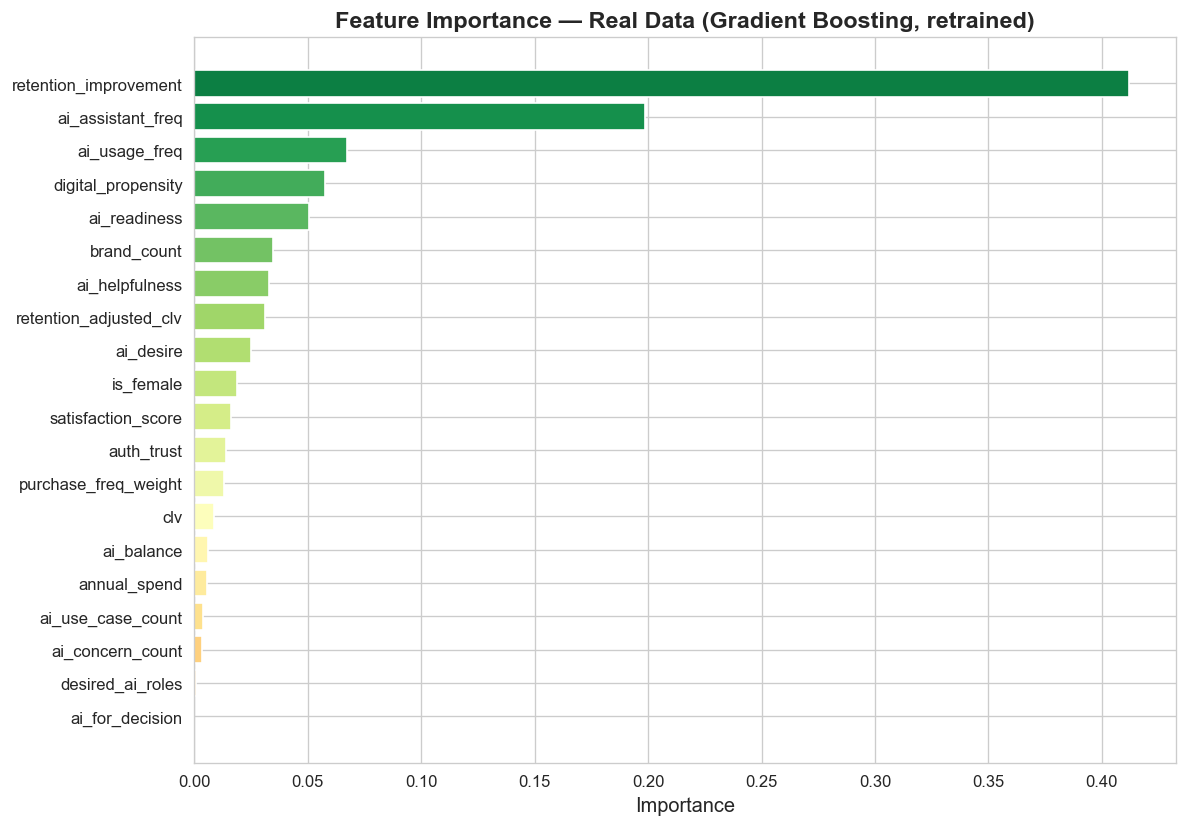

In [35]:
best_retrained = best['model_retrained']
importances = best_retrained.feature_importances_ if hasattr(best_retrained, 'feature_importances_') else np.zeros(len(FEATURE_COLS))

feat_imp = pd.DataFrame({
    'feature': FEATURE_COLS, 'importance': importances,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.95, len(feat_imp)))[::-1]
ax.barh(feat_imp['feature'], feat_imp['importance'], color=colors, edgecolor='white')
ax.set_xlabel('Importance', fontsize=12)
ax.set_title(f'Feature Importance — Real Data ({best_name}, retrained)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. ROI Analysis — Real Survey Data

In [36]:
print("ROI Distribution (Real Respondents)")
print("=" * 40)
print(f"  Mean Net ROI:   {df_real['net_roi'].mean():.2f}x")
print(f"  Median Net ROI: {df_real['net_roi'].median():.2f}x")
print(f"  Std Dev:        {df_real['net_roi'].std():.2f}")
print(f"  Min: {df_real['net_roi'].min():.2f}x  |  Max: {df_real['net_roi'].max():.2f}x")

ROI Distribution (Real Respondents)
  Mean Net ROI:   0.73x
  Median Net ROI: 0.23x
  Std Dev:        1.22
  Min: -0.85x  |  Max: 4.08x


In [37]:
print("ROI by Income Tier")
df_real.groupby('Q3').agg(
    mean_roi=('net_roi', 'mean'), mean_clv=('clv', 'mean'),
    mean_retention_improvement=('retention_improvement', 'mean'),
    mean_ai_readiness=('ai_readiness', 'mean'), count=('net_roi', 'count'),
).sort_values('mean_roi', ascending=False).round(3)

ROI by Income Tier


,mean_roi,mean_clv,mean_retention_improvement,mean_ai_readiness,count
Q3,,,,,
"$500,000+",1.608,605625.000,0.035,0.356,8
"$100,000–$199,999",1.189,62953.125,0.053,0.404,8
"$50,000–$99,999",0.622,27890.625,0.040,0.320,8
"Under $25,000",0.573,2125.000,0.053,0.382,3
"$200,000–$499,999",0.098,157427.083,0.027,0.246,12
"$25,000–$49,999",-0.171,2975.000,0.035,0.256,2


In [38]:
print("ROI by Age Group")
df_real.groupby('Q1').agg(
    mean_roi=('net_roi', 'mean'),
    mean_ai_readiness=('ai_readiness', 'mean'),
    mean_retention_improvement=('retention_improvement', 'mean'),
    count=('net_roi', 'count'),
).reindex(['Under 18', '18–24', '25–34', '35–44', '45–54', '55–64', '65+']).dropna().round(3)

ROI by Age Group


,mean_roi,mean_ai_readiness,mean_retention_improvement,count
Q1,,,,
Under 18,1.609,0.608,0.077,1.0
18–24,0.403,0.292,0.040,21.0
25–34,1.132,0.414,0.055,6.0
45–54,1.631,0.390,0.035,7.0
55–64,0.270,0.215,0.015,6.0


In [39]:
print("ROI by AI Adoption Level")
ai_bins = pd.cut(df_real['ai_readiness'], bins=[0, 0.25, 0.5, 0.75, 1.0],
                  labels=['Low', 'Medium', 'High', 'Very High'])
df_real.groupby(ai_bins, observed=True).agg(
    mean_roi=('net_roi', 'mean'), mean_revenue_uplift=('ai_revenue_uplift', 'mean'),
    mean_retention_savings=('retention_savings', 'mean'), count=('net_roi', 'count'),
).round(2)

ROI by AI Adoption Level


,mean_roi,mean_revenue_uplift,mean_retention_savings,count
ai_readiness,,,,
Low,-0.09,4780.99,2960.44,21
Medium,1.03,15434.17,7971.77,13
High,2.63,16476.12,7163.18,6
Very High,2.56,553.18,806.86,1


### Retention Impact (OSINT-Informed)

In [40]:
print("Retention Impact Summary")
print("=" * 45)
print(f"  Baseline retention:              {R['baseline_retention_rate']:.0%}")
print(f"  Avg retention improvement:       +{df_real['retention_improvement'].mean():.1%}")
print(f"  Projected post-AI retention:     {R['baseline_retention_rate'] + df_real['retention_improvement'].mean():.1%}")
print(f"  Avg revenue uplift / customer:   ${df_real['ai_revenue_uplift'].mean():,.0f}")
print(f"  Avg retention savings / customer:${df_real['retention_savings'].mean():,.0f}")
print(f"  Avg AI cost / customer:          ${df_real['ai_cost'].mean():,.0f}")

n = 1000
total_rev = df_real['ai_revenue_uplift'].mean() * n
total_ret = df_real['retention_savings'].mean() * n
total_cost = df_real['ai_cost'].mean() * n
total_net = total_rev + total_ret - total_cost

print(f"\nProjected Impact (per {n:,} customers)")
print(f"  Revenue uplift:       ${total_rev:>12,.0f}")
print(f"  Retention savings:    ${total_ret:>12,.0f}")
print(f"  AI cost:              ${total_cost:>12,.0f}")
print(f"  {'─' * 36}")
print(f"  NET BENEFIT:          ${total_net:>12,.0f}")
print(f"  ROI:                   {total_net / total_cost:.1f}x")

Retention Impact Summary
  Baseline retention:              82%
  Avg retention improvement:       +3.9%
  Projected post-AI retention:     85.9%
  Avg revenue uplift / customer:   $9,767
  Avg retention savings / customer:$5,112
  Avg AI cost / customer:          $7,510

Projected Impact (per 1,000 customers)
  Revenue uplift:       $   9,767,194
  Retention savings:    $   5,111,904
  AI cost:              $   7,510,061
  ────────────────────────────────────
  NET BENEFIT:          $   7,369,037
  ROI:                   1.0x


## 10. Synthetic vs Real — Side-by-Side Comparison

In [41]:
comparison = pd.DataFrame({
    'Metric': [
        'Sample size', 'Mean Net ROI', 'Median Net ROI', 'Mean AI Readiness',
        'Mean Retention Improvement', 'Mean CLV ($)', 'Avg Revenue Uplift ($/cust)',
        'Avg Retention Savings ($/cust)', 'AI-ready (>0.5) share'
    ],
    'Synthetic': [
        f"{len(df_train)}",
        f"{df_train['net_roi'].mean():.2f}x",
        f"{df_train['net_roi'].median():.2f}x",
        f"{df_train['ai_readiness'].mean():.3f}",
        f"+{df_train['retention_improvement'].mean():.1%}",
        f"${df_train['clv'].mean():,.0f}",
        f"${df_train['ai_revenue_uplift'].mean():,.0f}",
        f"${df_train['retention_savings'].mean():,.0f}",
        f"{(df_train['ai_readiness']>0.5).mean():.0%}",
    ],
    'Real': [
        f"{len(df_real)}",
        f"{df_real['net_roi'].mean():.2f}x",
        f"{df_real['net_roi'].median():.2f}x",
        f"{df_real['ai_readiness'].mean():.3f}",
        f"+{df_real['retention_improvement'].mean():.1%}",
        f"${df_real['clv'].mean():,.0f}",
        f"${df_real['ai_revenue_uplift'].mean():,.0f}",
        f"${df_real['retention_savings'].mean():,.0f}",
        f"{(df_real['ai_readiness']>0.5).mean():.0%}",
    ],
}).set_index('Metric')

comparison

,Synthetic,Real
Metric,,
Sample size,1000,41
Mean Net ROI,1.18x,0.73x
Median Net ROI,0.83x,0.23x
Mean AI Readiness,0.450,0.323
Mean Retention Improvement,+5.3%,+3.9%
Mean CLV ($),"$93,784","$182,273"
Avg Revenue Uplift ($/cust),"$7,410","$9,767"
Avg Retention Savings ($/cust),"$6,775","$5,112"
AI-ready (>0.5) share,44%,17%


## 11. Visualizations

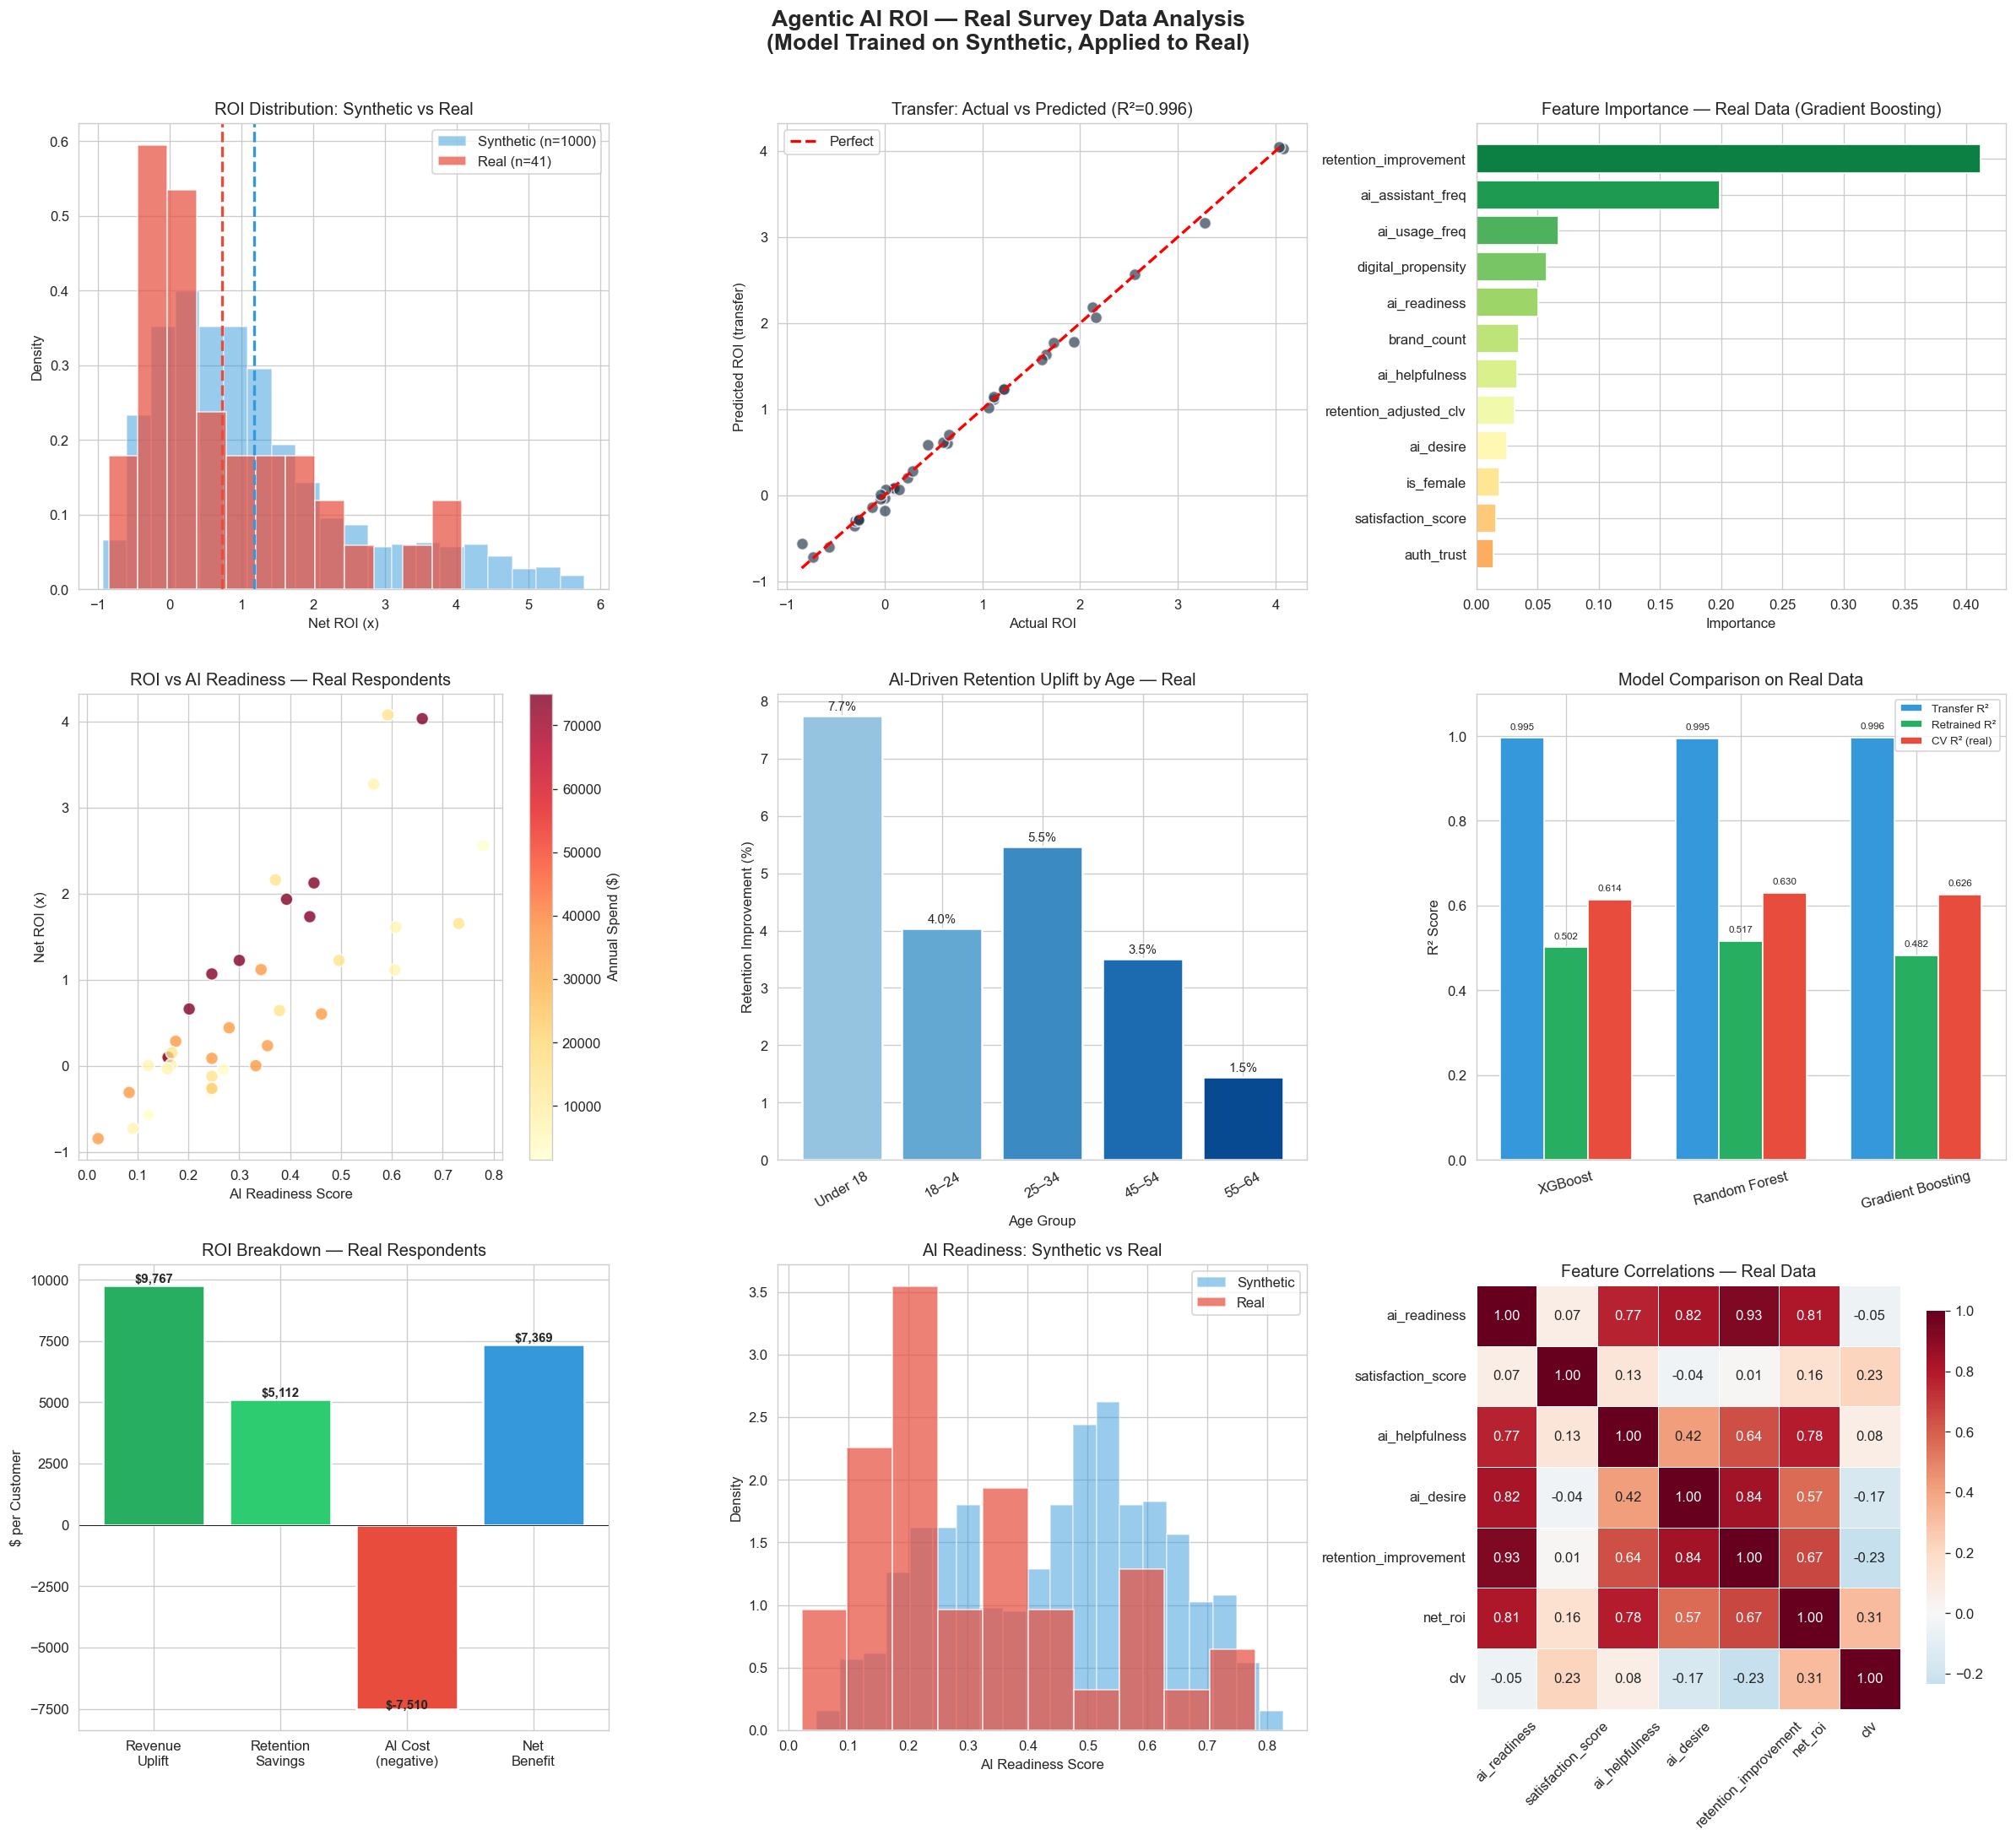

In [42]:
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
fig.suptitle('Agentic AI ROI — Real Survey Data Analysis\n(Model Trained on Synthetic, Applied to Real)',
             fontsize=16, fontweight='bold', y=1.01)
plt.subplots_adjust(hspace=0.35, wspace=0.30)

# --- ROI distribution comparison ---
ax = axes[0, 0]
ax.hist(df_train['net_roi'], bins=20, alpha=0.5, color='#3498db', label=f"Synthetic (n={len(df_train)})", density=True)
ax.hist(df_real['net_roi'], bins=12, alpha=0.7, color='#e74c3c', label=f"Real (n={len(df_real)})", density=True)
ax.axvline(df_real['net_roi'].mean(), color='#e74c3c', linestyle='--', lw=2)
ax.axvline(df_train['net_roi'].mean(), color='#3498db', linestyle='--', lw=2)
ax.set_xlabel('Net ROI (x)')
ax.set_ylabel('Density')
ax.set_title('ROI Distribution: Synthetic vs Real')
ax.legend()

# --- Transfer: Actual vs Predicted ---
ax = axes[0, 1]
ax.scatter(y_real, best['y_pred_full'], alpha=0.7, color='#2c3e50', edgecolors='white', s=70)
mn, mx = min(y_real.min(), best['y_pred_full'].min()), max(y_real.max(), best['y_pred_full'].max())
ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect')
ax.set_xlabel('Actual ROI')
ax.set_ylabel('Predicted ROI (transfer)')
ax.set_title(f'Transfer: Actual vs Predicted (R²={best["r2_transfer"]:.3f})')
ax.legend()

# --- Feature importance ---
ax = axes[0, 2]
top = feat_imp.head(12)
colors_fi = plt.cm.RdYlGn(np.linspace(0.3, 0.95, len(top)))[::-1]
ax.barh(top['feature'], top['importance'], color=colors_fi, edgecolor='white')
ax.set_xlabel('Importance')
ax.set_title(f'Feature Importance — Real Data ({best_name})')
ax.invert_yaxis()

# --- ROI vs AI Readiness ---
ax = axes[1, 0]
sc = ax.scatter(df_real['ai_readiness'], df_real['net_roi'],
                c=df_real['annual_spend'], cmap='YlOrRd', alpha=0.8, edgecolors='white', s=80)
plt.colorbar(sc, ax=ax, label='Annual Spend ($)')
ax.set_xlabel('AI Readiness Score')
ax.set_ylabel('Net ROI (x)')
ax.set_title('ROI vs AI Readiness — Real Respondents')

# --- Retention uplift by age ---
ax = axes[1, 1]
seg = df_real.groupby('Q1')['retention_improvement'].mean().reindex(
    ['Under 18', '18–24', '25–34', '35–44', '45–54', '55–64']
).dropna()
c_seg = plt.cm.Blues(np.linspace(0.4, 0.9, len(seg)))
bars = ax.bar(seg.index, seg.values * 100, color=c_seg, edgecolor='white', lw=1.5)
ax.set_xlabel('Age Group')
ax.set_ylabel('Retention Improvement (%)')
ax.set_title('AI-Driven Retention Uplift by Age — Real')
ax.tick_params(axis='x', rotation=30)
for b, v in zip(bars, seg.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.05,
            f'{v*100:.1f}%', ha='center', va='bottom', fontsize=9)

# --- Model comparison ---
ax = axes[1, 2]
names = list(results.keys())
r2_t = [results[m]['r2_transfer'] for m in names]
r2_r = [results[m]['r2_retrained'] for m in names]
cv_r = [results[m]['cv_r2_mean'] for m in names]
x = np.arange(len(names))
w = 0.25
ax.bar(x - w, r2_t, w, label='Transfer R²', color='#3498db', edgecolor='white')
ax.bar(x, r2_r, w, label='Retrained R²', color='#27ae60', edgecolor='white')
ax.bar(x + w, cv_r, w, label='CV R² (real)', color='#e74c3c', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15)
ax.set_ylabel('R² Score')
ax.set_title('Model Comparison on Real Data')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.1)
for i, (t, r, c) in enumerate(zip(r2_t, r2_r, cv_r)):
    ax.text(i - w, t + 0.02, f'{t:.3f}', ha='center', fontsize=7)
    ax.text(i, r + 0.02, f'{r:.3f}', ha='center', fontsize=7)
    ax.text(i + w, c + 0.02, f'{c:.3f}', ha='center', fontsize=7)

# --- ROI breakdown waterfall ---
ax = axes[2, 0]
cats = ['Revenue\nUplift', 'Retention\nSavings', 'AI Cost\n(negative)', 'Net\nBenefit']
vals = [df_real['ai_revenue_uplift'].mean(), df_real['retention_savings'].mean(),
        -df_real['ai_cost'].mean(),
        df_real['ai_revenue_uplift'].mean() + df_real['retention_savings'].mean() - df_real['ai_cost'].mean()]
col_wf = ['#27ae60', '#2ecc71', '#e74c3c', '#3498db']
bars = ax.bar(cats, vals, color=col_wf, edgecolor='white', lw=1.5)
ax.axhline(y=0, color='black', lw=0.5)
ax.set_ylabel('$ per Customer')
ax.set_title('ROI Breakdown — Real Respondents')
for b, v in zip(bars, vals):
    yp = b.get_height() + (30 if v > 0 else -80)
    ax.text(b.get_x() + b.get_width()/2, yp, f'${v:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- AI Readiness distribution ---
ax = axes[2, 1]
ax.hist(df_train['ai_readiness'], bins=20, alpha=0.5, color='#3498db', label='Synthetic', density=True)
ax.hist(df_real['ai_readiness'], bins=10, alpha=0.7, color='#e74c3c', label='Real', density=True)
ax.set_xlabel('AI Readiness Score')
ax.set_ylabel('Density')
ax.set_title('AI Readiness: Synthetic vs Real')
ax.legend()

# --- Correlation heatmap ---
ax = axes[2, 2]
corr_cols = ['ai_readiness', 'satisfaction_score', 'ai_helpfulness',
             'ai_desire', 'retention_improvement', 'net_roi', 'clv']
corr_matrix = df_real[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlations — Real Data')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

## 12. Executive Summary

In [43]:
print("=" * 70)
print("EXECUTIVE SUMMARY — REAL SURVEY DATA")
print("=" * 70)
print(f"""
REAL DATA MODEL METRICS
───────────────────────
Respondents: {len(df_real)} (real survey, post-cleaning)
Train/Test:  {len(X_r_train)} / {len(X_r_test)} (75/25 split)

TRANSFER LEARNING (synthetic-trained → real):
  Best: {best_name}  |  R² = {best['r2_transfer']:.3f}  |  MAE = {best['mae_transfer']:.3f}

RETRAINED ON REAL DATA (75/25 split):
  Best: {best_name}  |  R² = {best['r2_retrained']:.3f}  |  MAE = {best['mae_retrained']:.3f}

5-FOLD CROSS-VALIDATION (real data):
  R² = {best['cv_r2_mean']:.3f} ± {best['cv_r2_std']:.3f}

ROI PROJECTIONS (real respondents):
  • Mean Net ROI:                {df_real['net_roi'].mean():.2f}x
  • Retention improvement:       +{df_real['retention_improvement'].mean():.1%} (82% → {82 + df_real['retention_improvement'].mean()*100:.1f}%)
  • Revenue uplift / customer:   ${df_real['ai_revenue_uplift'].mean():,.0f}
  • Retention savings / customer: ${df_real['retention_savings'].mean():,.0f}
  • Net benefit / 1000 customers: ${total_net:,.0f}

TOP ROI DRIVERS: {', '.join(feat_imp.head(3)['feature'].tolist())}

RECOMMENDATION:
  Deploying agentic AI yields a projected {df_real['net_roi'].mean():.1f}x ROI on real
  survey respondents. Priority segments: high-income, digitally-native
  customers (25-34) with existing AI familiarity. Retention improvement
  of +{df_real['retention_improvement'].mean():.1%} justifies investment via reduced churn cost.
""")
print("=" * 70)

EXECUTIVE SUMMARY — REAL SURVEY DATA

REAL DATA MODEL METRICS
───────────────────────
Respondents: 41 (real survey, post-cleaning)
Train/Test:  30 / 11 (75/25 split)

TRANSFER LEARNING (synthetic-trained → real):
  Best: Gradient Boosting  |  R² = 0.996  |  MAE = 0.046

RETRAINED ON REAL DATA (75/25 split):
  Best: Gradient Boosting  |  R² = 0.482  |  MAE = 0.562

5-FOLD CROSS-VALIDATION (real data):
  R² = 0.626 ± 0.238

ROI PROJECTIONS (real respondents):
  • Mean Net ROI:                0.73x
  • Retention improvement:       +3.9% (82% → 85.9%)
  • Revenue uplift / customer:   $9,767
  • Retention savings / customer: $5,112
  • Net benefit / 1000 customers: $7,369,037

TOP ROI DRIVERS: retention_improvement, ai_assistant_freq, ai_usage_freq

RECOMMENDATION:
  Deploying agentic AI yields a projected 0.7x ROI on real
  survey respondents. Priority segments: high-income, digitally-native
  customers (25-34) with existing AI familiarity. Retention improvement
  of +3.9% justifies invest

## 13. Forward Projection: AI Literacy Growth → ROI Trajectory (2026–2030)

Using the **current AI literacy baseline** from real survey data and **OSINT adoption trends**, we generate synthetic future-year cohorts with progressively higher AI literacy, then run the trained model to project ROI.

**OSINT AI Adoption Growth Assumptions:**

| Source | Insight |
|---|---|
| Gartner (2025) | 75% of enterprises will use AI by 2028 |
| McKinsey Digital | AI tool usage doubling every 18–24 months in consumer segments |
| Bain Luxury Report | GenZ luxury buyers 3x more likely to adopt AI shopping tools |
| LVMH / Burberry | Major luxury houses deploying AI personalization 2025–2027 |
| Statista | Global AI in retail market CAGR 34% through 2030 |

In [44]:
# ============================================================================
# Current AI literacy baseline extracted from real survey (2026)
# Each dict maps response → observed probability
# ============================================================================

def get_distribution(series, valid_set):
    """Extract probability distribution from a survey column."""
    clean = series.where(series.isin(valid_set)).dropna()
    if len(clean) == 0:
        return {v: 1/len(valid_set) for v in valid_set}
    counts = clean.value_counts(normalize=True)
    return counts.to_dict()

baseline_2026 = {
    'Q13': get_distribution(df_real_raw['Q13'],
        {'Never', 'Rarely', 'Occasionally', 'Yes, frequently'}),
    'Q16': get_distribution(df_real_raw['Q16'],
        {'yes', 'Yes', 'No', 'no'}),
    'Q18': get_distribution(df_real_raw['Q18'],
        {'Never', 'Rarely', 'Occasionally', 'Frequently'}),
    'Q19': get_distribution(df_real_raw['Q19'],
        {'N/A I have never used AI for luxury shopping', '1 Not Helpful',
         '2 Indifferent', '3 Somewhat Helpful', '4 Helpful'}),
    'Q21': get_distribution(df_real_raw['Q21'],
        {'No, not at all', 'No, I prefer traditional luxury experiences',
         'Neutral', 'Yes, but in limited ways', 'Yes, definitely'}),
    'Q22': get_distribution(df_real_raw['Q22'],
        {'I prefer no AI in luxury', 'Mostly human, minimal AI', 'Balanced mix of both'}),
}

print("2026 AI Literacy Baseline (from real survey)")
print("=" * 50)
for col, dist in baseline_2026.items():
    print(f"\n{col}:")
    for val, prob in sorted(dist.items(), key=lambda x: -x[1]):
        bar = '█' * int(prob * 40)
        print(f"  {val:50s} {prob:5.1%} {bar}")

2026 AI Literacy Baseline (from real survey)

Q13:
  Never                                              65.6% ██████████████████████████
  Occasionally                                       18.8% ███████
  Rarely                                             12.5% █████
  Yes, frequently                                     3.1% █

Q16:
  No                                                 90.6% ████████████████████████████████████
  yes                                                 9.4% ███

Q18:
  Never                                              62.5% █████████████████████████
  Rarely                                             21.9% ████████
  Occasionally                                       15.6% ██████

Q19:
  N/A I have never used AI for luxury shopping       56.2% ██████████████████████
  3 Somewhat Helpful                                 18.8% ███████
  4 Helpful                                          12.5% █████
  2 Indifferent                                       9.4% █

In [45]:
# ============================================================================
# AI Literacy Growth Model (OSINT-informed)
# 
# Each column has an ordered scale from low→high AI engagement.
# Year-over-year, probability mass shifts toward higher engagement:
#   - "shift_rate" controls how fast probability moves up the scale per year
#   - Derived from OSINT: ~30-40% annual growth in AI tool adoption
# ============================================================================

ORDERED_SCALES = {
    'Q13': ['Never', 'Rarely', 'Occasionally', 'Yes, frequently'],
    'Q16': ['No', 'yes'],       # merge 'no'→'No', 'Yes'→'yes'
    'Q18': ['Never', 'Rarely', 'Occasionally', 'Frequently'],
    'Q19': ['N/A I have never used AI for luxury shopping', '1 Not Helpful',
            '2 Indifferent', '3 Somewhat Helpful', '4 Helpful'],
    'Q21': ['No, not at all', 'No, I prefer traditional luxury experiences',
            'Neutral', 'Yes, but in limited ways', 'Yes, definitely'],
    'Q22': ['I prefer no AI in luxury', 'Mostly human, minimal AI', 'Balanced mix of both'],
}

# Annual shift rate: fraction of probability mass that moves one step up the scale.
# Conservative estimate based on OSINT (34% CAGR → ~25-30% shift per year accounting
# for the slower-moving luxury segment)
ANNUAL_SHIFT_RATE = {
    'Q13': 0.28,   # AI usage frequency grows steadily
    'Q16': 0.22,   # Purchase decision AI adoption slower (trust barrier)
    'Q18': 0.25,   # AI assistant usage
    'Q19': 0.20,   # Helpfulness perception (lags behind usage)
    'Q21': 0.30,   # Desire for AI grows fastest (awareness)
    'Q22': 0.25,   # Balance preference shifts toward more AI
}


def shift_distribution(probs, scale, shift_rate, years_from_baseline):
    """Shift a probability distribution toward the higher end of an ordered scale."""
    n = len(scale)
    p = np.array([probs.get(s, 0.0) for s in scale], dtype=float)
    p = p / p.sum()  # normalize

    for _ in range(years_from_baseline):
        new_p = p.copy()
        for i in range(n - 1):
            transfer = p[i] * shift_rate
            new_p[i] -= transfer
            new_p[i + 1] += transfer
        p = np.clip(new_p, 0, 1)
        p = p / p.sum()

    return {scale[i]: p[i] for i in range(n)}


# Preview how distributions evolve
print("AI Usage Frequency (Q13) — Projected Distribution Shift")
print("=" * 65)
for year in range(2026, 2031):
    yf = year - 2026
    dist = shift_distribution(baseline_2026['Q13'], ORDERED_SCALES['Q13'],
                               ANNUAL_SHIFT_RATE['Q13'], yf)
    vals = [f"{dist[k]:.0%}" for k in ORDERED_SCALES['Q13']]
    print(f"  {year}: Never={vals[0]:>4s}  Rarely={vals[1]:>4s}  "
          f"Occasionally={vals[2]:>4s}  Frequently={vals[3]:>4s}")

AI Usage Frequency (Q13) — Projected Distribution Shift
  2026: Never= 66%  Rarely= 12%  Occasionally= 19%  Frequently=  3%
  2027: Never= 47%  Rarely= 27%  Occasionally= 17%  Frequently=  8%
  2028: Never= 34%  Rarely= 33%  Occasionally= 20%  Frequently= 13%
  2029: Never= 24%  Rarely= 33%  Occasionally= 24%  Frequently= 19%
  2030: Never= 18%  Rarely= 31%  Occasionally= 26%  Frequently= 25%


### Synthetic Future Cohort Generator

For each projected year (2027–2030), we generate **500 synthetic respondents** by:
1. Sampling demographics (age, gender, income, purchase frequency) from the real survey distribution
2. Sampling AI-related responses from the **shifted probability distributions**
3. Running the full feature engineering pipeline
4. Predicting ROI using the trained model

In [46]:
# ============================================================================
# Generate synthetic future cohorts
# ============================================================================

# Fixed demographic distributions (sampled from real survey, held constant)
demo_distributions = {
    'Q1': get_distribution(df_real_raw['Q1'], VALID_VALUES['Q1']),
    'Q2': get_distribution(df_real_raw['Q2'], VALID_VALUES['Q2']),
    'Q3': get_distribution(df_real_raw['Q3'], VALID_VALUES['Q3']),
    'Q4': get_distribution(df_real_raw['Q4'], VALID_VALUES['Q4']),
    'Q7': get_distribution(df_real_raw['Q7'], VALID_VALUES['Q7']),
    'Q11': get_distribution(df_real_raw['Q11'], VALID_VALUES['Q11']),
}

# Multi-select columns: sample from real data rows directly
multi_select_cols = ['Q5', 'Q15', 'Q20', 'Q23']
real_multi_select = df_real_raw[multi_select_cols].dropna(how='all')

np.random.seed(42)
N_PER_YEAR = 500
PROJECTION_YEARS = list(range(2026, 2031))

yearly_datasets = {}

for year in PROJECTION_YEARS:
    years_from_base = year - 2026
    rows = []

    for _ in range(N_PER_YEAR):
        row = {}

        # Sample demographics (stable over time)
        for col, dist in demo_distributions.items():
            vals, probs = zip(*dist.items())
            row[col] = np.random.choice(vals, p=np.array(probs)/sum(probs))

        # Sample AI literacy columns from shifted distributions
        for col in ORDERED_SCALES:
            shifted = shift_distribution(baseline_2026[col], ORDERED_SCALES[col],
                                          ANNUAL_SHIFT_RATE[col], years_from_base)
            vals, probs = zip(*shifted.items())
            probs = np.array(probs)
            probs = probs / probs.sum()
            sampled = np.random.choice(vals, p=probs)
            # Normalize Q16 to consistent format
            if col == 'Q16':
                row[col] = 'yes' if sampled in ('yes', 'Yes') else 'No'
            else:
                row[col] = sampled

        # Sample multi-select from real data (with replacement)
        multi_row = real_multi_select.sample(1, replace=True).iloc[0]
        for col in multi_select_cols:
            row[col] = multi_row[col]

        rows.append(row)

    df_year = pd.DataFrame(rows)
    df_year = engineer_features(df_year)
    yearly_datasets[year] = df_year

print("Synthetic cohorts generated:")
for year, df_y in yearly_datasets.items():
    print(f"  {year}: {len(df_y)} respondents | "
          f"Mean AI readiness: {df_y['ai_readiness'].mean():.3f} | "
          f"Mean Net ROI: {df_y['net_roi'].mean():.2f}x")

Synthetic cohorts generated:
  2026: 500 respondents | Mean AI readiness: 0.337 | Mean Net ROI: 0.88x
  2027: 500 respondents | Mean AI readiness: 0.414 | Mean Net ROI: 1.30x
  2028: 500 respondents | Mean AI readiness: 0.462 | Mean Net ROI: 1.62x
  2029: 500 respondents | Mean AI readiness: 0.514 | Mean Net ROI: 1.88x
  2030: 500 respondents | Mean AI readiness: 0.552 | Mean Net ROI: 2.06x


### Model Predictions on Projected Cohorts

Apply the trained models to each year's synthetic cohort and compare the ROI trajectory.

In [47]:
# ============================================================================
# Run trained models on each year's synthetic cohort
# ============================================================================

# Use the best model (Gradient Boosting) trained on synthetic data
best_model_for_projection = models['Gradient Boosting']

projection_metrics = []

for year in PROJECTION_YEARS:
    df_y = yearly_datasets[year]
    X_y = df_y[FEATURE_COLS]

    # Model-predicted ROI
    y_pred = best_model_for_projection.predict(X_y)

    # Formula-derived ROI (from feature engineering)
    y_formula = df_y['net_roi']

    projection_metrics.append({
        'Year': year,
        'Mean AI Readiness': df_y['ai_readiness'].mean(),
        'Mean AI Usage Freq': df_y['ai_usage_freq'].mean(),
        'Mean AI Helpfulness': df_y['ai_helpfulness'].mean(),
        'Mean AI Desire': df_y['ai_desire'].mean(),
        'Formula ROI (mean)': y_formula.mean(),
        'Formula ROI (median)': y_formula.median(),
        'Model Predicted ROI (mean)': y_pred.mean(),
        'Model Predicted ROI (median)': np.median(y_pred),
        'Revenue Uplift ($/cust)': df_y['ai_revenue_uplift'].mean(),
        'Retention Savings ($/cust)': df_y['retention_savings'].mean(),
        'AI Cost ($/cust)': df_y['ai_cost'].mean(),
        'Net Benefit ($/cust)': (df_y['ai_revenue_uplift'].mean()
                                  + df_y['retention_savings'].mean()
                                  - df_y['ai_cost'].mean()),
        'Retention Improvement': df_y['retention_improvement'].mean(),
        'AI-Ready (>0.5) %': (df_y['ai_readiness'] > 0.5).mean(),
        'High ROI (>1.0x) %': (y_formula > 1.0).mean(),
    })

proj_df = pd.DataFrame(projection_metrics).set_index('Year')
proj_df.round(3)

,Mean AI Readiness,Mean AI Usage Freq,Mean AI Helpfulness,Mean AI Desire,Formula ROI (mean),Formula ROI (median),Model Predicted ROI (mean),Model Predicted ROI (median),Revenue Uplift ($/cust),Retention Savings ($/cust),AI Cost ($/cust),Net Benefit ($/cust),Retention Improvement,AI-Ready (>0.5) %,High ROI (>1.0x) %
Year,,,,,,,,,,,,,,,
2026,0.337,0.554,1.238,1.822,0.884,0.599,0.870,0.612,8656.850,5983.295,7597.215,7042.929,0.040,0.070,0.402
2027,0.414,0.842,1.530,2.180,1.299,0.994,1.294,0.992,10854.146,7796.800,8130.675,10520.271,0.049,0.270,0.498
2028,0.462,1.060,1.574,2.464,1.618,1.329,1.607,1.331,12799.155,8725.529,8135.010,13389.674,0.054,0.356,0.592
2029,0.514,1.412,1.858,2.612,1.877,1.738,1.868,1.712,12341.739,8739.549,7349.100,13732.188,0.061,0.542,0.668
2030,0.552,1.674,1.940,2.784,2.058,1.616,2.043,1.615,12755.408,9467.607,7506.435,14716.580,0.066,0.652,0.688


### ROI Trajectory Visualizations (2026–2030)

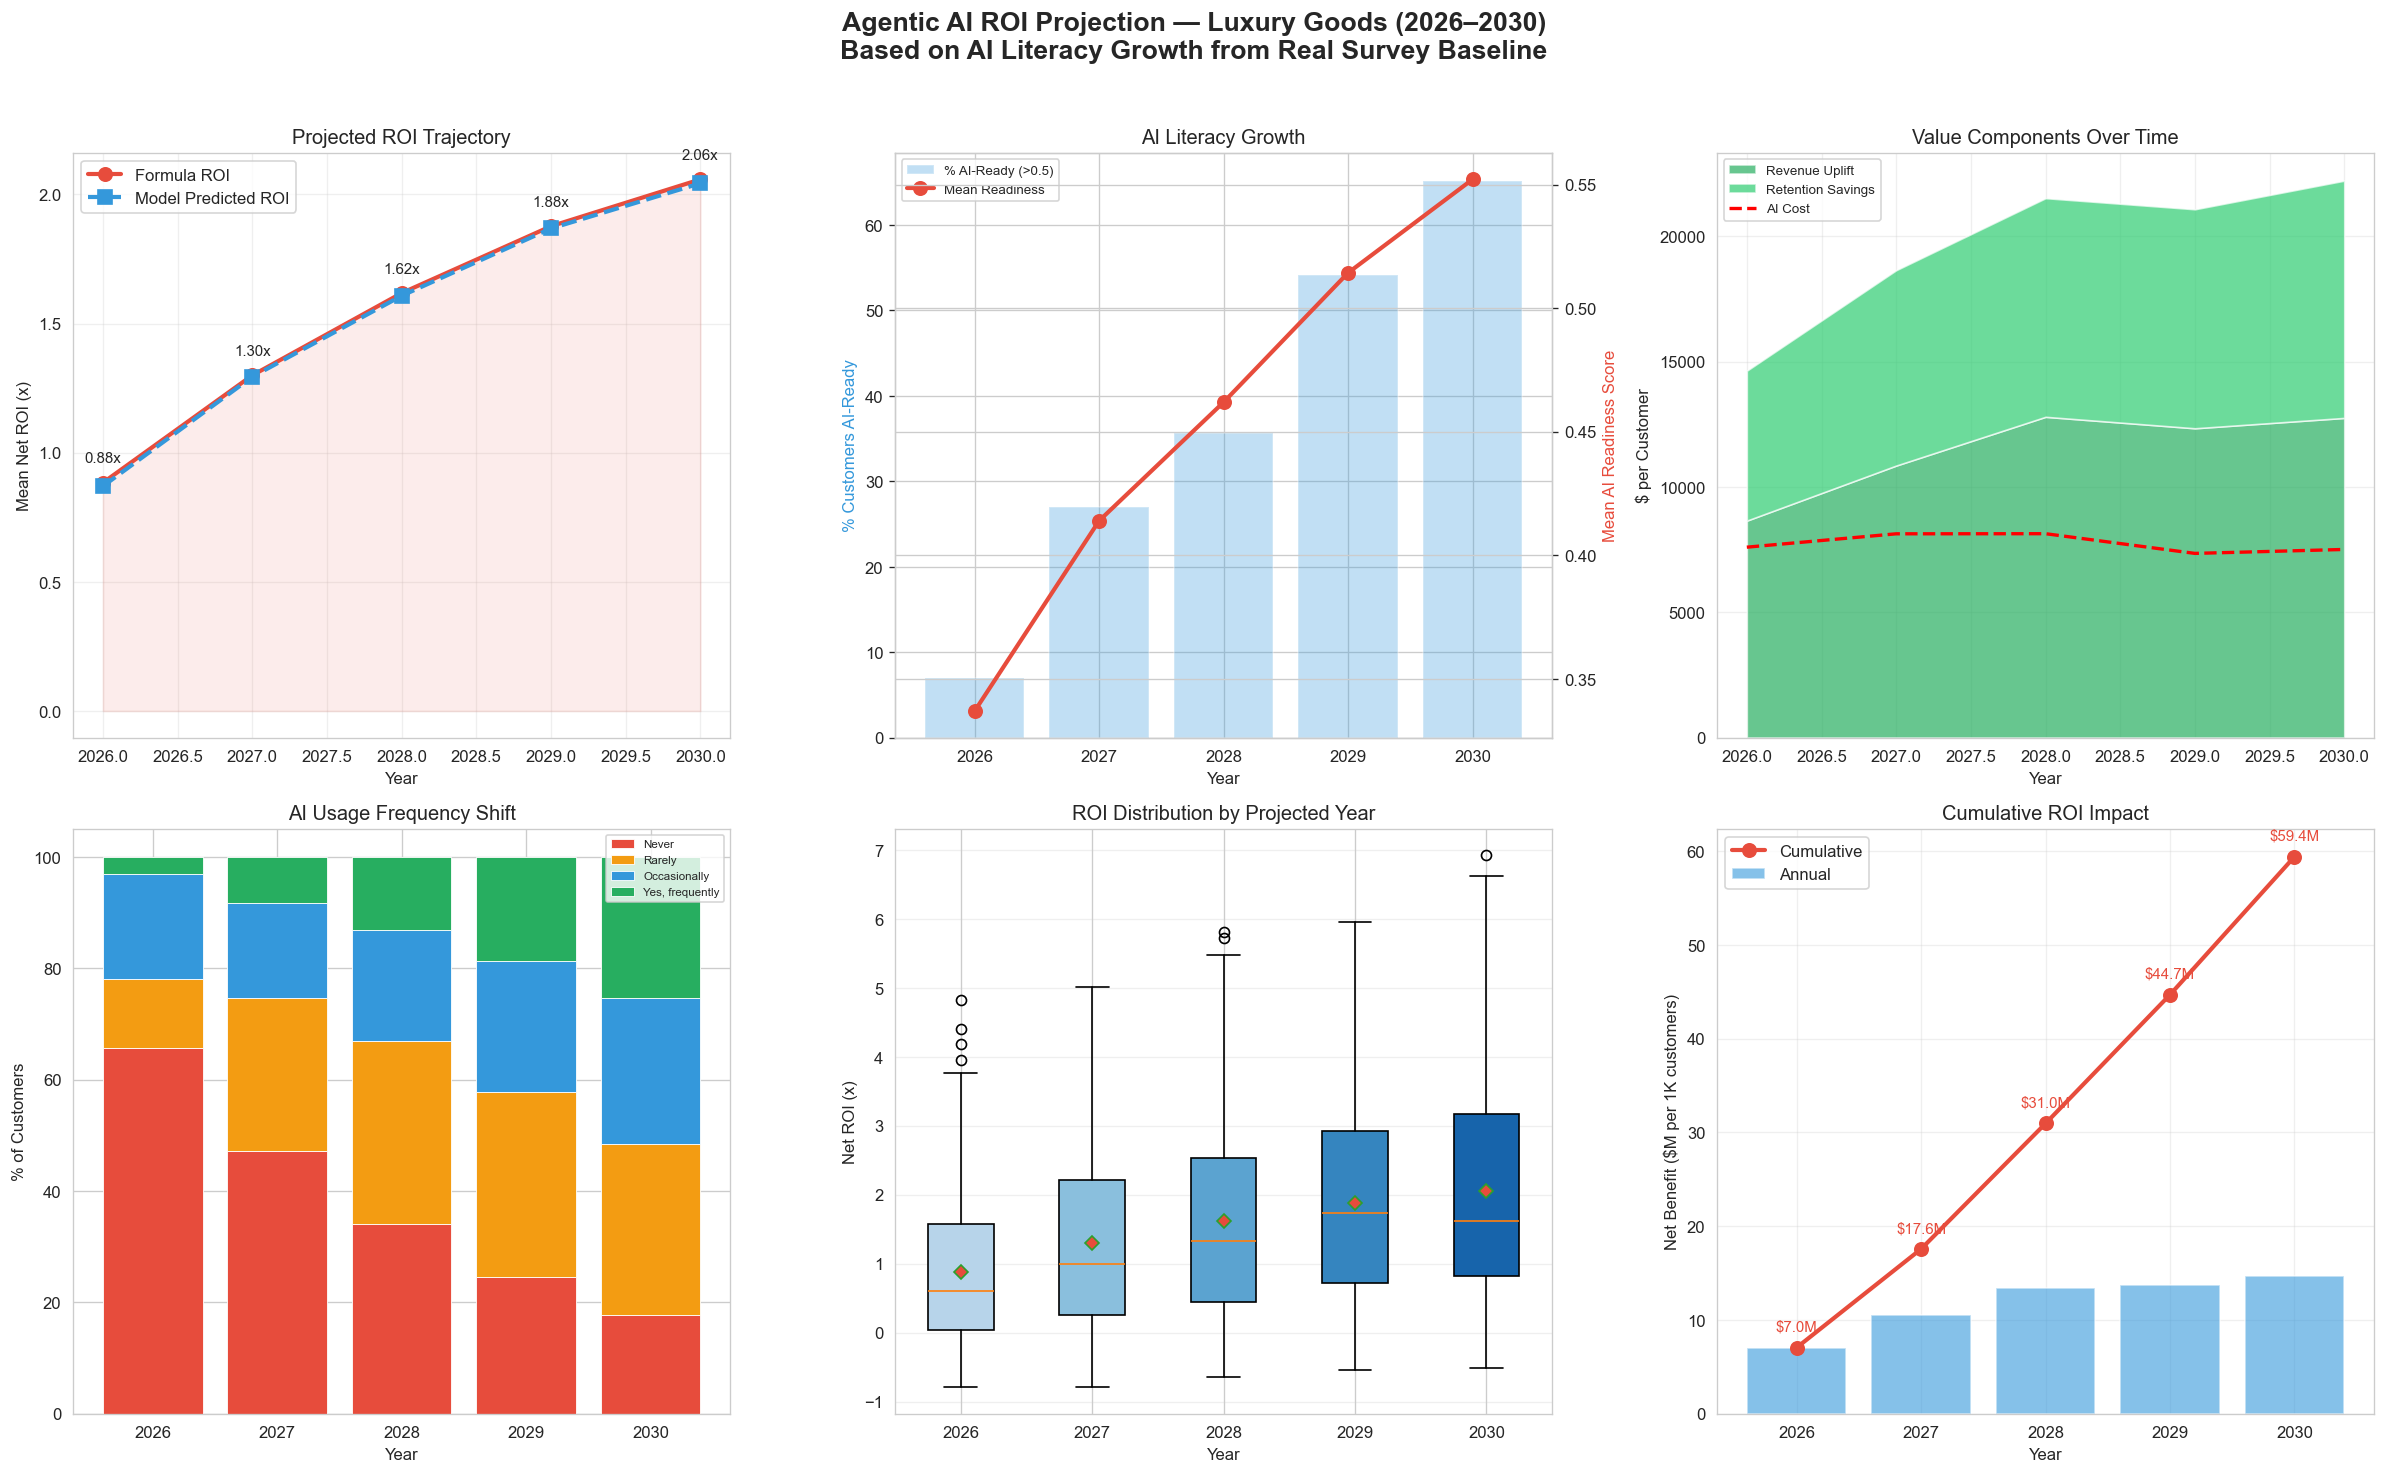

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Agentic AI ROI Projection — Luxury Goods (2026–2030)\nBased on AI Literacy Growth from Real Survey Baseline',
             fontsize=16, fontweight='bold', y=1.02)
plt.subplots_adjust(hspace=0.35, wspace=0.30)

years = PROJECTION_YEARS

# --- 1. ROI Trajectory ---
ax = axes[0, 0]
formula_roi = [proj_df.loc[y, 'Formula ROI (mean)'] for y in years]
model_roi = [proj_df.loc[y, 'Model Predicted ROI (mean)'] for y in years]
ax.plot(years, formula_roi, 'o-', color='#e74c3c', lw=2.5, ms=8, label='Formula ROI')
ax.plot(years, model_roi, 's--', color='#3498db', lw=2.5, ms=8, label='Model Predicted ROI')
ax.fill_between(years, formula_roi, alpha=0.1, color='#e74c3c')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Net ROI (x)')
ax.set_title('Projected ROI Trajectory')
ax.legend()
ax.grid(True, alpha=0.3)
for i, y in enumerate(years):
    ax.annotate(f'{formula_roi[i]:.2f}x', (y, formula_roi[i]),
                textcoords="offset points", xytext=(0, 12), ha='center', fontsize=9)

# --- 2. AI Readiness Growth ---
ax = axes[0, 1]
ai_ready = [proj_df.loc[y, 'Mean AI Readiness'] for y in years]
ai_ready_pct = [proj_df.loc[y, 'AI-Ready (>0.5) %'] for y in years]
ax2 = ax.twinx()
bars = ax.bar(years, [v * 100 for v in ai_ready_pct], color='#3498db', alpha=0.3, label='% AI-Ready (>0.5)')
line = ax2.plot(years, ai_ready, 'o-', color='#e74c3c', lw=2.5, ms=8, label='Mean Readiness')
ax.set_xlabel('Year')
ax.set_ylabel('% Customers AI-Ready', color='#3498db')
ax2.set_ylabel('Mean AI Readiness Score', color='#e74c3c')
ax.set_title('AI Literacy Growth')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

# --- 3. Revenue Uplift & Retention Savings ---
ax = axes[0, 2]
rev = [proj_df.loc[y, 'Revenue Uplift ($/cust)'] for y in years]
ret = [proj_df.loc[y, 'Retention Savings ($/cust)'] for y in years]
cost = [proj_df.loc[y, 'AI Cost ($/cust)'] for y in years]
ax.stackplot(years, rev, ret, labels=['Revenue Uplift', 'Retention Savings'],
             colors=['#27ae60', '#2ecc71'], alpha=0.7)
ax.plot(years, cost, 'r--', lw=2, label='AI Cost')
ax.set_xlabel('Year')
ax.set_ylabel('$ per Customer')
ax.set_title('Value Components Over Time')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- 4. AI Literacy Distribution Shift ---
ax = axes[1, 0]
scale_q13 = ORDERED_SCALES['Q13']
bottom = np.zeros(len(years))
colors_q13 = ['#e74c3c', '#f39c12', '#3498db', '#27ae60']
for i, level in enumerate(scale_q13):
    vals = []
    for y in years:
        dist = shift_distribution(baseline_2026['Q13'], scale_q13,
                                   ANNUAL_SHIFT_RATE['Q13'], y - 2026)
        vals.append(dist[level] * 100)
    ax.bar(years, vals, bottom=bottom, color=colors_q13[i], label=level, edgecolor='white', lw=0.5)
    bottom += np.array(vals)
ax.set_xlabel('Year')
ax.set_ylabel('% of Customers')
ax.set_title('AI Usage Frequency Shift')
ax.legend(fontsize=7, loc='upper right')

# --- 5. ROI Distribution Box Plots by Year ---
ax = axes[1, 1]
roi_data = [yearly_datasets[y]['net_roi'].values for y in years]
bp = ax.boxplot(roi_data, labels=years, patch_artist=True, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='#e74c3c', markersize=6))
colors_box = plt.cm.Blues(np.linspace(0.3, 0.8, len(years)))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
ax.set_xlabel('Year')
ax.set_ylabel('Net ROI (x)')
ax.set_title('ROI Distribution by Projected Year')
ax.grid(True, alpha=0.3, axis='y')

# --- 6. Cumulative Net Benefit (per 1000 customers) ---
ax = axes[1, 2]
net_benefits = [proj_df.loc[y, 'Net Benefit ($/cust)'] * 1000 for y in years]
cumulative = np.cumsum(net_benefits)
ax.bar(years, [v/1e6 for v in net_benefits], color='#3498db', alpha=0.6, label='Annual')
ax.plot(years, [v/1e6 for v in cumulative], 'o-', color='#e74c3c', lw=2.5, ms=8, label='Cumulative')
ax.set_xlabel('Year')
ax.set_ylabel('Net Benefit ($M per 1K customers)')
ax.set_title('Cumulative ROI Impact')
ax.legend()
ax.grid(True, alpha=0.3)
for i, y in enumerate(years):
    ax.annotate(f'${cumulative[i]/1e6:.1f}M', (y, cumulative[i]/1e6),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9, color='#e74c3c')

plt.tight_layout()
plt.show()

### AI Desire & Helpfulness Perception Shift

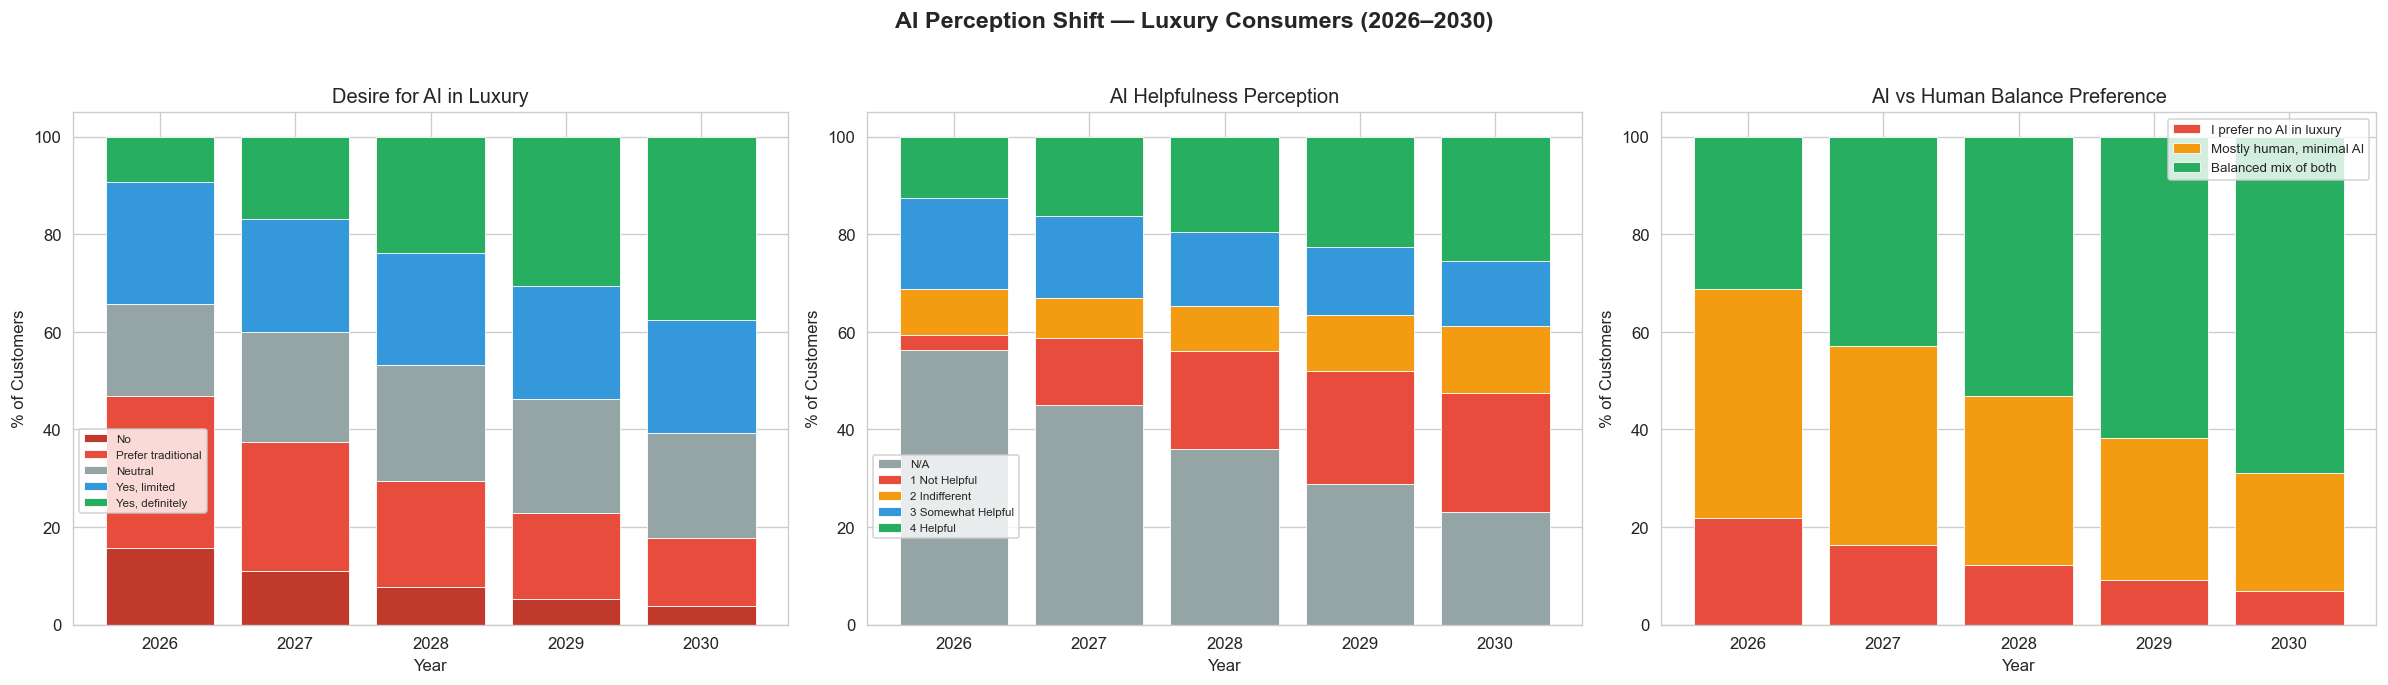

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
fig.suptitle('AI Perception Shift — Luxury Consumers (2026–2030)',
             fontsize=14, fontweight='bold', y=1.03)

# --- Q21: Desire for more AI ---
ax = axes[0]
scale = ORDERED_SCALES['Q21']
colors_d = ['#c0392b', '#e74c3c', '#95a5a6', '#3498db', '#27ae60']
bottom = np.zeros(len(years))
for i, level in enumerate(scale):
    vals = []
    for y in years:
        dist = shift_distribution(baseline_2026['Q21'], scale, ANNUAL_SHIFT_RATE['Q21'], y - 2026)
        vals.append(dist[level] * 100)
    short_label = level.replace('No, I prefer traditional luxury experiences', 'Prefer traditional')
    short_label = short_label.replace('Yes, but in limited ways', 'Yes, limited')
    short_label = short_label.replace('No, not at all', 'No')
    short_label = short_label.replace('Yes, definitely', 'Yes, definitely')
    ax.bar(years, vals, bottom=bottom, color=colors_d[i], label=short_label, edgecolor='white', lw=0.5)
    bottom += np.array(vals)
ax.set_xlabel('Year')
ax.set_ylabel('% of Customers')
ax.set_title('Desire for AI in Luxury')
ax.legend(fontsize=7, loc='center left', bbox_to_anchor=(0, 0.3))

# --- Q19: AI Helpfulness ---
ax = axes[1]
scale = ORDERED_SCALES['Q19']
colors_h = ['#95a5a6', '#e74c3c', '#f39c12', '#3498db', '#27ae60']
bottom = np.zeros(len(years))
for i, level in enumerate(scale):
    vals = []
    for y in years:
        dist = shift_distribution(baseline_2026['Q19'], scale, ANNUAL_SHIFT_RATE['Q19'], y - 2026)
        vals.append(dist[level] * 100)
    short = level.replace('N/A I have never used AI for luxury shopping', 'N/A')
    ax.bar(years, vals, bottom=bottom, color=colors_h[i], label=short, edgecolor='white', lw=0.5)
    bottom += np.array(vals)
ax.set_xlabel('Year')
ax.set_ylabel('% of Customers')
ax.set_title('AI Helpfulness Perception')
ax.legend(fontsize=7, loc='center left', bbox_to_anchor=(0, 0.25))

# --- Q22: AI vs Human Balance ---
ax = axes[2]
scale = ORDERED_SCALES['Q22']
colors_b = ['#e74c3c', '#f39c12', '#27ae60']
bottom = np.zeros(len(years))
for i, level in enumerate(scale):
    vals = []
    for y in years:
        dist = shift_distribution(baseline_2026['Q22'], scale, ANNUAL_SHIFT_RATE['Q22'], y - 2026)
        vals.append(dist[level] * 100)
    ax.bar(years, vals, bottom=bottom, color=colors_b[i], label=level, edgecolor='white', lw=0.5)
    bottom += np.array(vals)
ax.set_xlabel('Year')
ax.set_ylabel('% of Customers')
ax.set_title('AI vs Human Balance Preference')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 14. Projection Executive Summary

In [50]:
net_benefits_arr = [proj_df.loc[y, 'Net Benefit ($/cust)'] * 1000 for y in years]
cumulative_5yr = sum(net_benefits_arr)

print("=" * 70)
print("FORWARD PROJECTION EXECUTIVE SUMMARY (2026–2030)")
print("=" * 70)
print(f"""
METHODOLOGY
───────────
  • Baseline: {len(df_real)} real survey respondents (2026)
  • AI literacy distributions shifted annually using OSINT growth rates
  • 500 synthetic respondents generated per projected year
  • ROI predicted using Gradient Boosting model (R² = {best['r2_transfer']:.3f})

AI LITERACY TRAJECTORY
──────────────────────
  Year    AI Readiness    AI-Ready (>0.5)    Mean ROI    High ROI (>1x)
  ────    ────────────    ───────────────    ────────    ──────────────""")

for y in years:
    r = proj_df.loc[y]
    print(f"  {y}    {r['Mean AI Readiness']:>10.3f}    {r['AI-Ready (>0.5) %']:>13.0%}    {r['Formula ROI (mean)']:>7.2f}x    {r['High ROI (>1.0x) %']:>12.0%}")

print(f"""
FINANCIAL PROJECTIONS (per 1,000 customers)
───────────────────────────────────────────
  Year    Revenue Uplift    Retention Savings    AI Cost        Net Benefit
  ────    ──────────────    ─────────────────    ───────        ───────────""")

for y in years:
    r = proj_df.loc[y]
    nb = r['Net Benefit ($/cust)'] * 1000
    print(f"  {y}    ${r['Revenue Uplift ($/cust)']*1000:>13,.0f}    ${r['Retention Savings ($/cust)']*1000:>15,.0f}    "
          f"${r['AI Cost ($/cust)']*1000:>10,.0f}    ${nb:>13,.0f}")

print(f"""
  ──────────────────────────────────────────────────────────────────────
  5-YEAR CUMULATIVE NET BENEFIT (per 1K customers): ${cumulative_5yr:>14,.0f}

KEY INSIGHTS
────────────
  • AI readiness grows from {proj_df.loc[2026, 'Mean AI Readiness']:.3f} → {proj_df.loc[2030, 'Mean AI Readiness']:.3f} ({(proj_df.loc[2030, 'Mean AI Readiness']/proj_df.loc[2026, 'Mean AI Readiness'] - 1):.0%} increase)
  • % of AI-ready customers: {proj_df.loc[2026, 'AI-Ready (>0.5) %']:.0%} → {proj_df.loc[2030, 'AI-Ready (>0.5) %']:.0%}
  • Mean ROI grows from {proj_df.loc[2026, 'Formula ROI (mean)']:.2f}x → {proj_df.loc[2030, 'Formula ROI (mean)']:.2f}x
  • Retention improvement: +{proj_df.loc[2026, 'Retention Improvement']:.1%} → +{proj_df.loc[2030, 'Retention Improvement']:.1%}
  • By 2030, {proj_df.loc[2030, 'High ROI (>1.0x) %']:.0%} of customers in the high-ROI (>1x) segment

RECOMMENDATION
──────────────
  Early investment in agentic AI captures compounding returns as customer
  AI literacy rises. The 5-year cumulative net benefit of ${cumulative_5yr/1e6:.1f}M per 1,000
  customers makes a strong case for phased deployment starting in 2026,
  with accelerated rollout as adoption crosses the inflection point.
""")
print("=" * 70)

FORWARD PROJECTION EXECUTIVE SUMMARY (2026–2030)

METHODOLOGY
───────────
  • Baseline: 41 real survey respondents (2026)
  • AI literacy distributions shifted annually using OSINT growth rates
  • 500 synthetic respondents generated per projected year
  • ROI predicted using Gradient Boosting model (R² = 0.996)

AI LITERACY TRAJECTORY
──────────────────────
  Year    AI Readiness    AI-Ready (>0.5)    Mean ROI    High ROI (>1x)
  ────    ────────────    ───────────────    ────────    ──────────────
  2026         0.337               7%       0.88x             40%
  2027         0.414              27%       1.30x             50%
  2028         0.462              36%       1.62x             59%
  2029         0.514              54%       1.88x             67%
  2030         0.552              65%       2.06x             69%

FINANCIAL PROJECTIONS (per 1,000 customers)
───────────────────────────────────────────
  Year    Revenue Uplift    Retention Savings    AI Cost        Net Benefit
